<a href="https://colab.research.google.com/github/Budagam-Haasini/Machine_learning_project_batch18/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv('/content/circuits.csv');
df

,circuitId,circuitRef,name,location,country,lat,lng,alt,url
0,1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
1,2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
2,3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
3,4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
4,5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park
...,...,...,...,...,...,...,...,...,...
72,75,portimao,Autódromo Internacional do Algarve,Portimão,Portugal,37.22700,-8.62670,108,http://en.wikipedia.org/wiki/Algarve_Internati...
73,76,mugello,Autodromo Internazionale del Mugello,Mugello,Italy,43.99750,11.37190,255,http://en.wikipedia.org/wiki/Mugello_Circuit
74,77,jeddah,Jeddah Corniche Circuit,Jeddah,Saudi Arabia,21.63190,39.10440,15,http://en.wikipedia.org/wiki/Jeddah_Street_Cir...
75,78,losail,Losail International Circuit,Al Daayen,Qatar,25.49000,51.45420,12,http://en.wikipedia.org/wiki/Losail_Internatio...


IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

LOAD + PREPROCESS DATA

In [ ]:
results = pd.read_csv("results.csv")
races = pd.read_csv("races.csv")
status = pd.read_csv("status.csv")

df = results.merge(races, on="raceId")
df = df.merge(status, on="statusId")

# Target variable (DNF)
df["DNF"] = df["status"].apply(lambda x: 0 if x == "Finished" else 1)

# SPEED + BETTER ACCURACY BALANCE
df = df.sample(n=7000, random_state=42)

features = ["grid", "laps", "year"]
X = df[features].fillna(0)
y = df["DNF"]

TRAIN-TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def evaluate(name, y_test, y_pred, y_prob, color_cmap):
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", pre)
    print("Recall:", rec)
    print("F1:", f1)
    print("AUC:", auc)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=color_cmap)
    plt.title(name + " Confusion Matrix")
    plt.show()

    plot_color_map = {
        "Blues": "blue",
        "Greens": "green",
        "Oranges": "orange",
        "Purples": "purple"
    }
    plot_line_color = plot_color_map.get(color_cmap, "gray")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, color=plot_line_color, label=f"AUC={auc:.2f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(name + " ROC Curve")
    plt.legend()
    plt.show()

    return acc, pre, rec, f1, auc

LOGISTIC REGRESSION


Logistic BEFORE
Accuracy: 0.8152380952380952
Precision: 0.8506900878293601
Recall: 0.900398406374502
F1: 0.8748387096774194
AUC: 0.8610378910843719


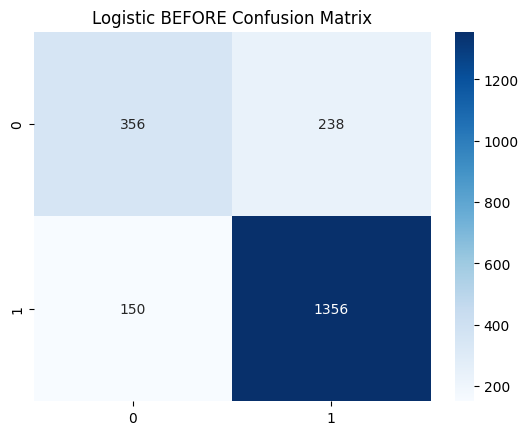

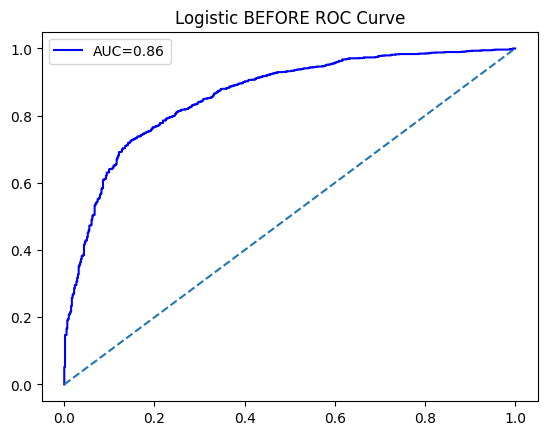

In [ ]:
lr_base = LogisticRegression(max_iter=500)
lr_base.fit(X_train_scaled, y_train)

y_pred_lr_base = lr_base.predict(X_test_scaled)
y_prob_lr_base = lr_base.predict_proba(X_test_scaled)[:,1]

# Storing base model metrics, if needed separately. Final `acc_lr` etc. will come from GridSearchCV.
acc_lr_base, pre_lr_base, rec_lr_base, f1_lr_base, auc_lr_base = evaluate(
    "Logistic BEFORE", y_test, y_pred_lr_base, y_prob_lr_base, "Blues"
)

cv_lr_base = cross_val_score(lr_base, X_train_scaled, y_train, cv=3).mean()


SVM BEFORE
Accuracy: 0.8252380952380952
Precision: 0.854828660436137
Recall: 0.9110225763612217
F1: 0.8820315011250401
AUC: 0.8638202521004645


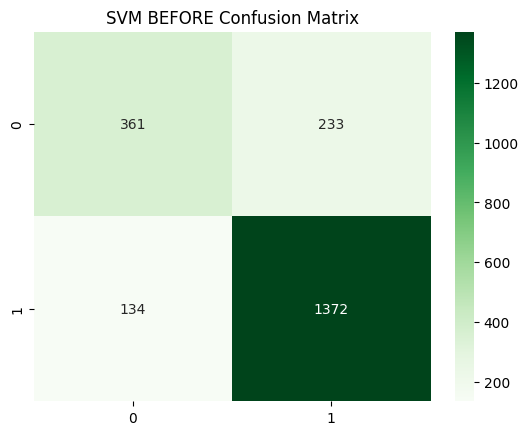

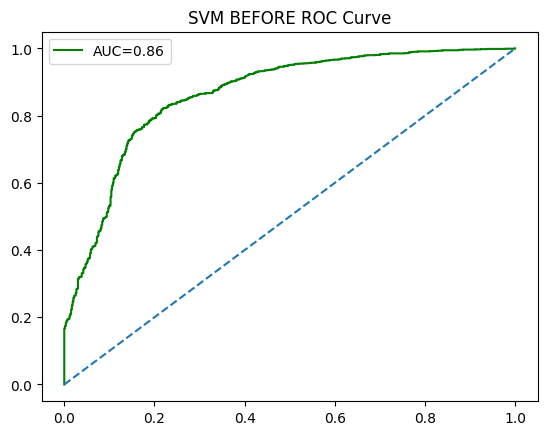

(0.8252380952380952,
 0.854828660436137,
 0.9110225763612217,
 0.8820315011250401,
 np.float64(0.8638202521004645))

In [ ]:
svm_base = SVC(probability=True)
svm_base.fit(X_train_scaled, y_train)

y_pred = svm_base.predict(X_test_scaled)
y_prob = svm_base.predict_proba(X_test_scaled)[:,1]

evaluate("SVM BEFORE", y_test, y_pred, y_prob, "Greens")


SVM AFTER
Accuracy: 0.8042857142857143
Precision: 0.8033240997229917
Recall: 0.9628154050464808
F1: 0.8758683177287828
AUC: 0.8611452059327225


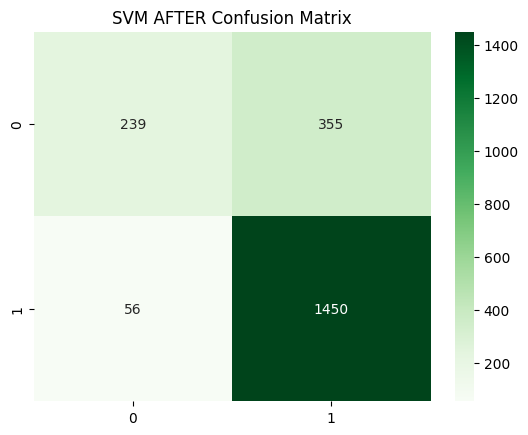

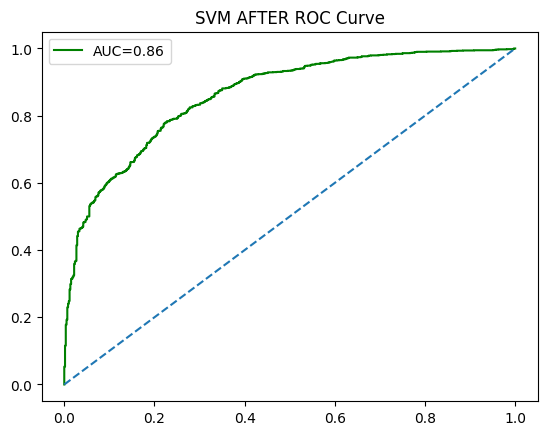

In [ ]:
#after
svm_grid = GridSearchCV(
    SVC(probability=True),
    {"C":[1,10], "kernel":["poly"]},
    cv=3
)

svm_grid.fit(X_train_scaled, y_train)
svm_best = svm_grid.best_estimator_

y_pred = svm_best.predict(X_test_scaled)
y_prob = svm_best.predict_proba(X_test_scaled)[:,1]

acc_svm, pre_svm, rec_svm, f1_svm, auc_svm = evaluate(
    "SVM AFTER", y_test, y_pred, y_prob, "Greens"
)

cv_svm = cross_val_score(svm_best, X, y, cv=3).mean()


Logistic AFTER (Poly Features)
Accuracy: 0.8152380952380952
Precision: 0.8506900878293601
Recall: 0.900398406374502
F1: 0.8748387096774194
AUC: 0.8694229814747743


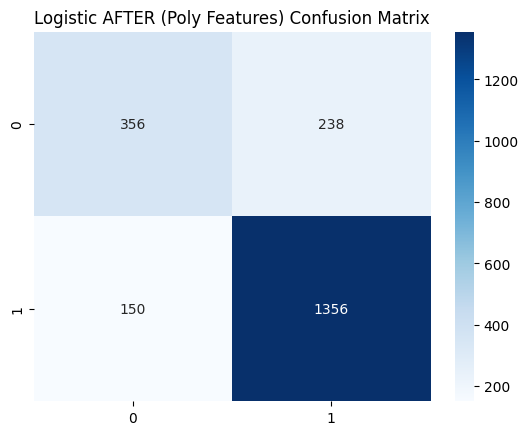

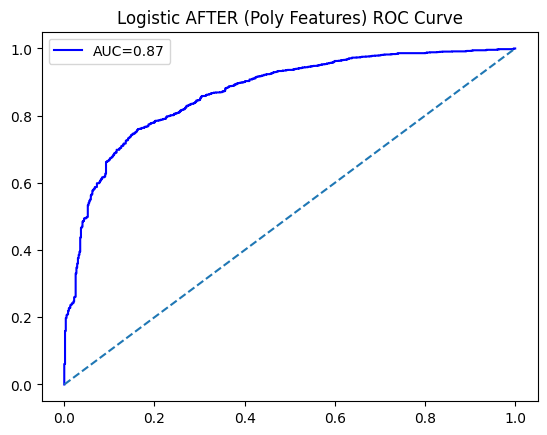

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Logistic Regression with GridSearchCV (AFTER optimization)
poly = PolynomialFeatures(degree=2) # Using degree 2 for polynomial features
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=500),
    {"C":[0.1, 1, 10], "solver":["liblinear", "lbfgs"]},
    cv=3
)

lr_grid.fit(X_train_poly, y_train)
lr_best = lr_grid.best_estimator_

y_pred = lr_best.predict(X_test_poly)
y_prob = lr_best.predict_proba(X_test_poly)[:,1]

acc_lr, pre_lr, rec_lr, f1_lr, auc_lr = evaluate(
    "Logistic AFTER (Poly Features)", y_test, y_pred, y_prob, "Blues"
)

cv_lr = cross_val_score(lr_best, X_train_poly, y_train, cv=3).mean()

SVM


SVM BEFORE
Accuracy: 0.8252380952380952
Precision: 0.854828660436137
Recall: 0.9110225763612217
F1: 0.8820315011250401
AUC: 0.8638297539359957


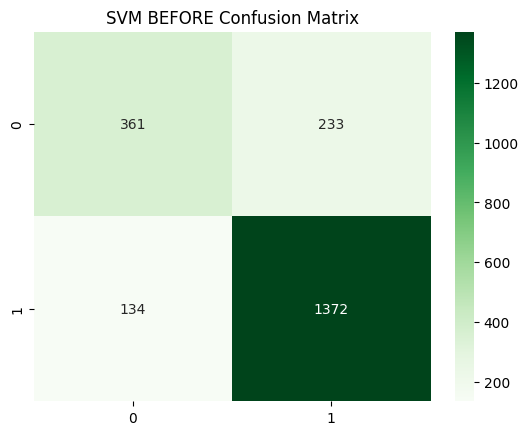

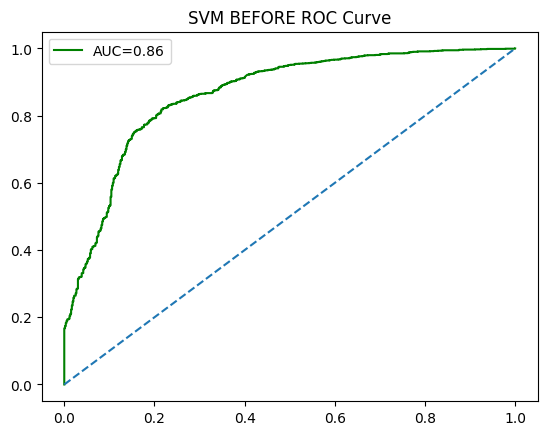

(0.8252380952380952,
 0.854828660436137,
 0.9110225763612217,
 0.8820315011250401,
 np.float64(0.8638297539359957))

In [ ]:
svm_base = SVC(probability=True)
svm_base.fit(X_train_scaled, y_train)

y_pred = svm_base.predict(X_test_scaled)
y_prob = svm_base.predict_proba(X_test_scaled)[:,1]

evaluate("SVM BEFORE", y_test, y_pred, y_prob, "Greens")


SVM AFTER
Accuracy: 0.8042857142857143
Precision: 0.8033240997229917
Recall: 0.9628154050464808
F1: 0.8758683177287828
AUC: 0.8611362630286934


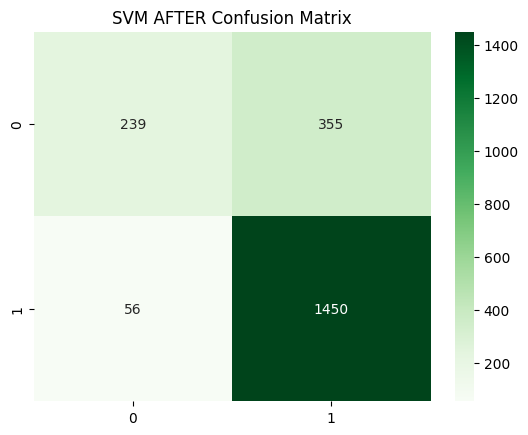

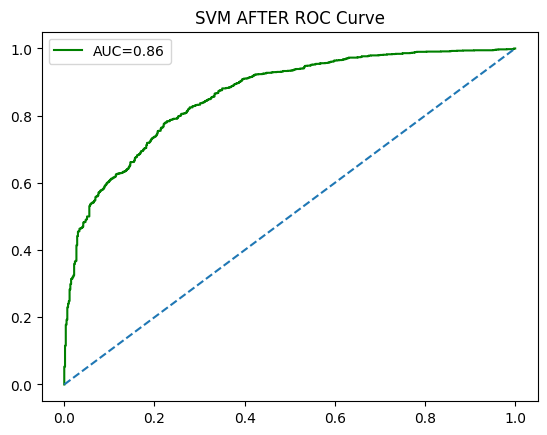

In [ ]:
#after
svm_grid = GridSearchCV(
    SVC(probability=True),
    {"C":[1,10], "kernel":["poly"]},
    cv=3
)

svm_grid.fit(X_train_scaled, y_train)
svm_best = svm_grid.best_estimator_

y_pred = svm_best.predict(X_test_scaled)
y_prob = svm_best.predict_proba(X_test_scaled)[:,1]

acc_svm, pre_svm, rec_svm, f1_svm, auc_svm = evaluate(
    "SVM AFTER", y_test, y_pred, y_prob, "Greens"
)

cv_svm = cross_val_score(svm_best, X, y, cv=3).mean()

KNN


KNN BEFORE
Accuracy: 0.8095238095238095
Precision: 0.8604954367666232
Recall: 0.8764940239043825
F1: 0.868421052631579
AUC: 0.8593963092635072


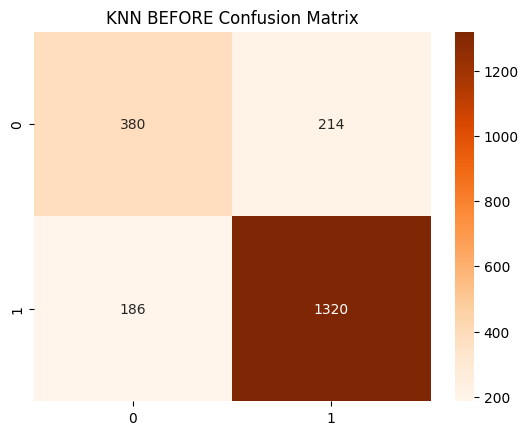

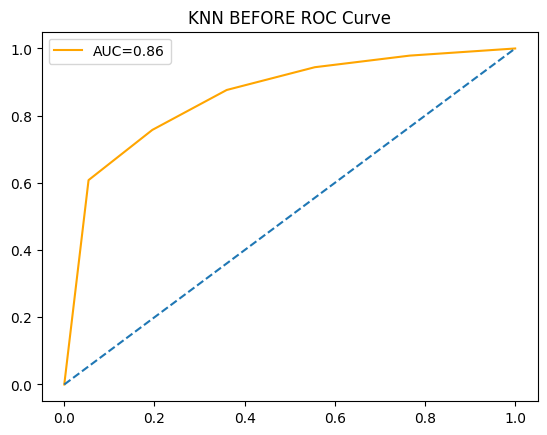

(0.8095238095238095,
 0.8604954367666232,
 0.8764940239043825,
 0.868421052631579,
 np.float64(0.8593963092635072))

In [ ]:
knn_base = KNeighborsClassifier(n_neighbors=5)
knn_base.fit(X_train_scaled, y_train)

y_pred = knn_base.predict(X_test_scaled)
y_prob = knn_base.predict_proba(X_test_scaled)[:,1]

evaluate("KNN BEFORE", y_test, y_pred, y_prob, "Oranges")


KNN AFTER
Accuracy: 0.8095238095238095
Precision: 0.8604954367666232
Recall: 0.8764940239043825
F1: 0.868421052631579
AUC: 0.8593963092635072


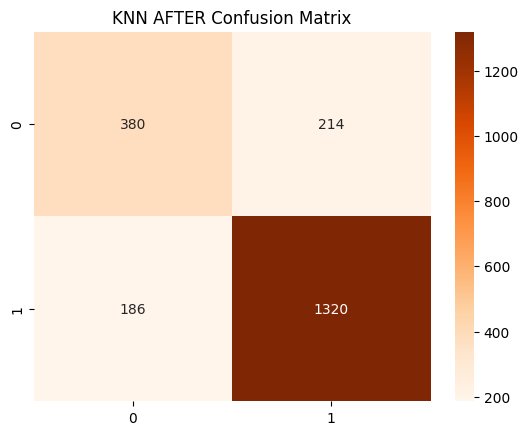

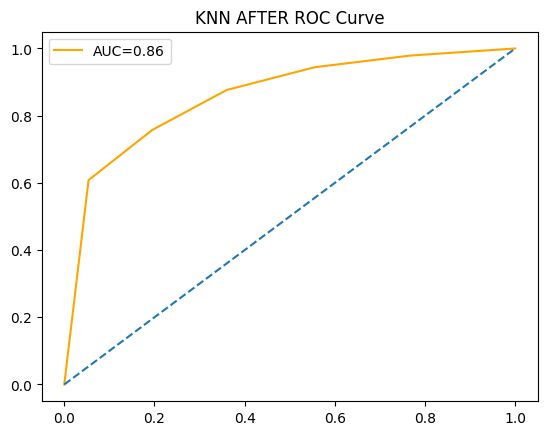

In [ ]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors":[3,5], "weights":["uniform","distance"]},
    cv=3
)

knn_grid.fit(X_train_scaled, y_train)
knn_best = knn_grid.best_estimator_

y_pred = knn_best.predict(X_test_scaled)
y_prob = knn_best.predict_proba(X_test_scaled)[:,1]

acc_knn, pre_knn, rec_knn, f1_knn, auc_knn = evaluate(
    "KNN AFTER", y_test, y_pred, y_prob, "Oranges"
)

cv_knn = cross_val_score(knn_best, X_train_scaled, y_train, cv=3).mean()

Random forest


RF BEFORE
Accuracy: 0.8519047619047619
Precision: 0.8923177938279712
Recall: 0.9023904382470119
F1: 0.8973258501155497
AUC: 0.920352819921213


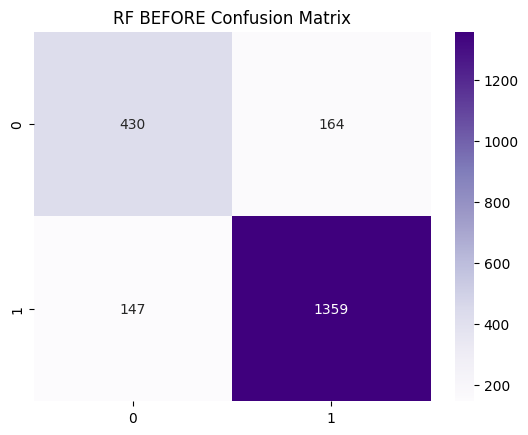

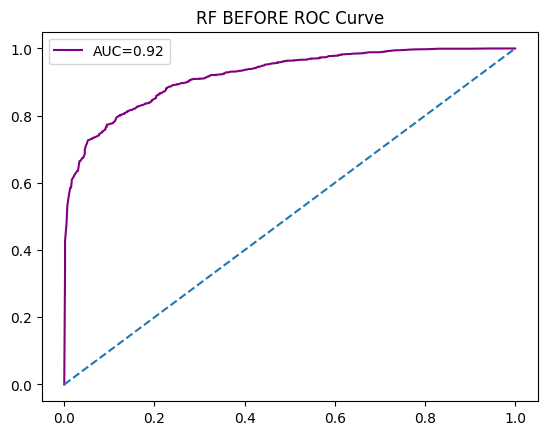

(0.8519047619047619,
 0.8923177938279712,
 0.9023904382470119,
 0.8973258501155497,
 np.float64(0.920352819921213))

In [ ]:
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)
y_prob = rf_base.predict_proba(X_test)[:,1]

evaluate("RF BEFORE", y_test, y_pred, y_prob, "Purples")


RF AFTER
Accuracy: 0.8571428571428571
Precision: 0.8920676202860858
Recall: 0.9110225763612217
F1: 0.9014454664914586
AUC: 0.9251015019607318


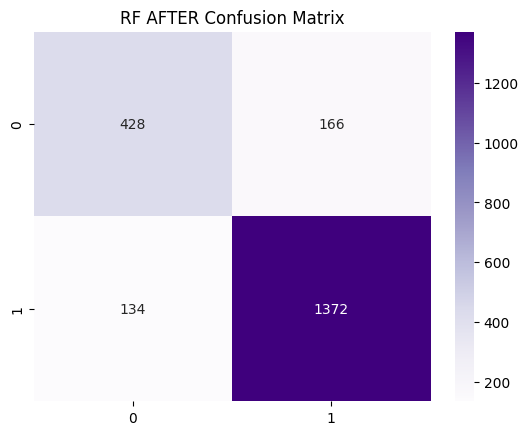

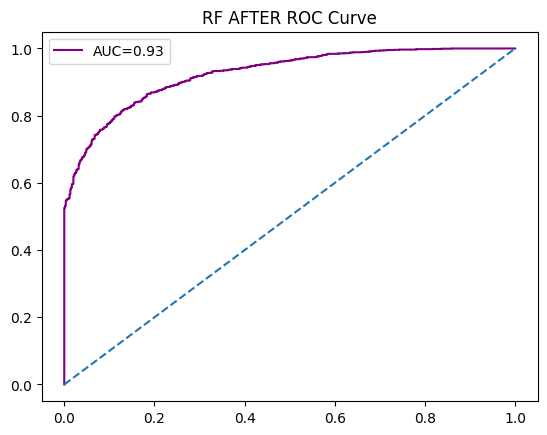

In [ ]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators":[100,200], "max_depth":[10,20]},
    cv=3
)

rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_

y_pred = rf_best.predict(X_test)
y_prob = rf_best.predict_proba(X_test)[:,1]

acc_rf, pre_rf, rec_rf, f1_rf, auc_rf = evaluate(
    "RF AFTER", y_test, y_pred, y_prob, "Purples"
)

cv_rf = cross_val_score(rf_best, X_train, y_train, cv=3).mean()

In [ ]:
results = pd.DataFrame({
    "Model":["LR","SVM","KNN","RF"],
    "Accuracy":[acc_lr,acc_svm,acc_knn,acc_rf],
    "Precision":[pre_lr,pre_svm,pre_knn,pre_rf],
    "Recall":[rec_lr,rec_svm,rec_knn,rec_rf],
    "F1":[f1_lr,f1_svm,f1_knn,f1_rf],
    "AUC":[auc_lr,auc_svm,auc_knn,auc_rf],
    "CV":[cv_lr,cv_svm,cv_knn,cv_rf]
})

print(results)

  Model  Accuracy  Precision    Recall        F1       AUC        CV
0    LR  0.815238   0.850690  0.900398  0.874839  0.869423  0.812041
1   SVM  0.804286   0.803324  0.962815  0.875868  0.861136  0.807428
2   KNN  0.809524   0.860495  0.876494  0.868421  0.859396  0.811430
3    RF  0.857143   0.892068  0.911023  0.901445  0.925102  0.846326


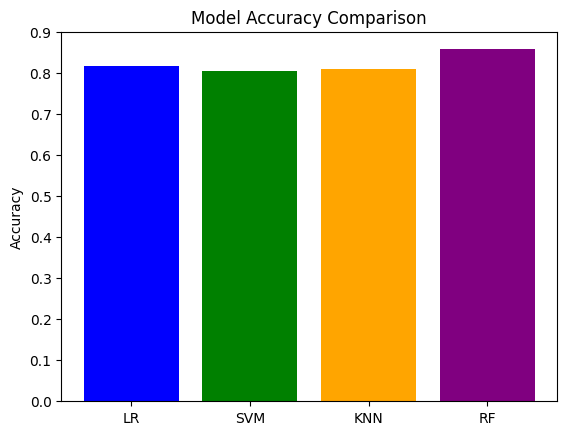

In [ ]:
plt.bar(results["Model"], results["Accuracy"], color=["blue","green","orange","purple"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
best = results.sort_values(by="Accuracy", ascending=False)
print("\nBest Model:\n", best.head(1))


Best Model:
   Model  Accuracy  Precision    Recall        F1       AUC        CV
3    RF  0.857143   0.892068  0.911023  0.901445  0.925102  0.846326


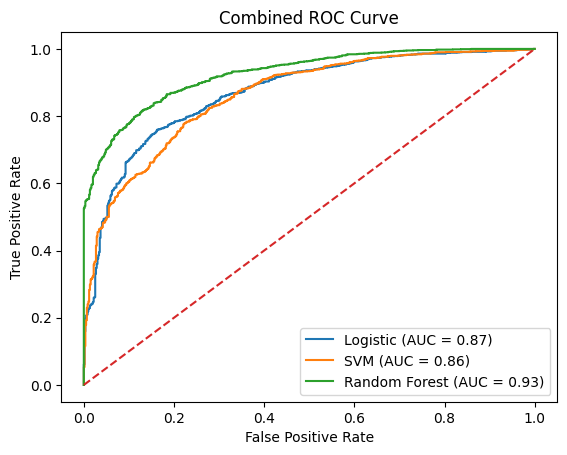

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression (use best model if you want)
y_prob_lr = lr_best.predict_proba(X_test_poly)[:,1]

# SVM
y_prob_svm = svm_best.predict_proba(X_test_scaled)[:,1]

# Random Forest
y_prob_rf = rf_best.predict_proba(X_test)[:,1]

# Calculate ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# AUC Scores
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot all together
plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC = {auc_lr:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

# Diagonal line (random guess)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Combined ROC Curve")
plt.legend()

plt.show()